# SiC Spectra

In [3]:
## General purpose
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import scipy as sp
import scipy.fft
import scipy.optimize as sp
import os
import time
import datetime
import scipy.signal
import matplotlib.colors as cls
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import importlib
import pprint
from tqdm import tqdm
import glob
import re
from scipy import stats
import qcodes as qc
import sys
from scipy.optimize import curve_fit
import scipy.signal as peak
from pathlib import Path
import matplotlib.ticker as ticker

# Dppend parent directory (longterm_sweeps) to sys.path -> search for files in this branch
sys.path.append(r"C:\Users\Mario\Documents\GitHub\Drivers")

# Import functions!!
import qil_helpers.Angela.angelaHelpers as ang

In [4]:
def process_spectra_by_freq(folderPath, numBins, 
                    intTime, excTime, countTime, deadCycle, aom, 
                    fit, fitWhichBins, ylims,
                    save = False, savePath = None, csvName = None):

    # READ INPUT DIRECTORY
    sortedFolders = sorted(folderPath,
                            key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
        
    # EXTRACT DATA
    freqsVpeaksAll = {}
    fitsAll = {}
    fits = {}

    for i, wave in enumerate(subFolderWavelengths):
        totalCounts = []
        freqs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter = ",")
            times, data = fileRead[0], fileRead[1]
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins - 1])

            timeLimit = times[numBins - 1] # sum over given histogram time interval
            totalCounts.append(counts)
            freqs.append(freq + float(aom))

        # INITIALISE FOR DATA STORAGE
        freqs = np.array(freqs)
        totalCounts = np.array(totalCounts)
        sortIdx = np.argsort(freqs)
        freqs = freqs[sortIdx]
        totalCounts = totalCounts[sortIdx]
   
        # NORMALISE TO COUNTS PER SECOND
        periodTTL = (excTime + countTime) * (deadCycle + 1) # [s]
        countTimeTotal = (intTime/periodTTL) * timeLimit # [s]
        countsPerSecond = totalCounts / countTimeTotal

        # # MASK SATURATED COUNTS PER SECOND
        # ylim = ylims[i] # select limits for each site
        # maxLim = ylim[1] # maximum 
        # mask = countsPerSecond < maxLim

        # freqs = freqs[mask]
        # countsPerSecond = countsPerSecond[mask]
        dataProcessed = pd.DataFrame({
            'Frequency (MHz)': freqs,
            'Counts per second': countsPerSecond
        })

        # FIT SPECTRUM
        if fit:
            try:
                whichBins = slice(fitWhichBins[0], fitWhichBins[1])
                # dataFit = np.column_stack(((freqsProcessed[whichBins])/1e3, 
                #                         countsPerSecondProcessed[whichBins])) # fit in GHz
                dataFit = np.column_stack(((freqs[whichBins])/1e3, 
                                        countsPerSecond[whichBins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(dataFit, None)
                fits = {
                    'x0': x0[0], 
                    'x0_err': x0[1],
                    'gamma': gamma[0], 
                    'gamma_err': gamma[1],
                    'A': A[0], 
                    'A_err': A[1],
                    'B': B[0], 
                    'B_err': B[1],
                    'C': C[0],
                    'C_err': C[1]
                    }
            except Exception as e:
                fits = None

        # STORE HERE AS DICTIONARY
        freqsVpeaksAll[wave] = dataProcessed
        fitsAll[wave] = fits

    # FLATTEN DICTIONARY TO SAVE DATA, FITS, AND TIMELIMIT
    if save:
        os.makedirs(savePath, exist_ok = True)
        for wave, df in freqsVpeaksAll.items():
            filename = f"{wave}_spectrum_{csvName}.csv"
            df.to_csv(os.path.join(savePath, filename), index = False)

        fits_df = pd.DataFrame.from_dict(fitsAll)
        fits_df = fits_df.reset_index()
        fits_df.to_csv(os.path.join(savePath, "lorentzian_fits.csv"), index = False)
            
    return freqsVpeaksAll, fitsAll, timeLimit

def plot_single_spectrum(x, y, cols, figsize, site, timeLimit, aom = None, lines = True, norm = True, fits = None,
                  save = False, savePath = None, xLabel = None, plotDesc = None):
     
     # NORMALISE 
     if norm:
          y = y / np.max(y)
     range = max(y) - min(y)
     minLim = min(y) - 0.05 * range
     maxLim = max(y) + 0.2 * range

     # PLOT SPECTRUM
     fig = plt.figure(figsize = (figsize[0], figsize[1]))
     ax0 = fig.add_subplot(1, 1, 1)
     ax0.scatter(x, y, c = cols[0], s = 5) 
     
     # FORMATTING TICKS
     ax0.xaxis.set_major_locator(ticker.MultipleLocator(4))
     ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1))
     # ax0.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
     # ax0.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
     ax0.tick_params(axis = 'both', labelsize = 12) 
     ax0.ticklabel_format(useOffset = False, style = 'plain')
     plt.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
     plt.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)

     # PLOT LINES
     if lines:
          ax0.vlines((site[1]/1e3), minLim, maxLim,
                    colors = cols[1], linewidth = 1,
                    label = f'Published f$_0$')
          
     # PLOT FIT
     if fits is not None:
          xFit = np.linspace(min(x), max(x), 500)
          x0 = fits['x0']
          x0_err = fits['x0_err']
          gamma = fits['gamma']
          gamma_err = fits['gamma_err']
          A = fits['A']
          B = fits['B']
          C = fits['C']
          lorentzianFitted = ang.asym_lorentzian(xFit, x0, gamma, A, B, C)

          if norm:
               ax0.vlines((x0), minLim, maxLim,
                         colors = cols[3], linewidth = 1,
                         label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz' )
               ax0.plot(xFit, lorentzianFitted / max(lorentzianFitted),
                    c = cols[2], linewidth = 1.5,
                    label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')
          if norm == False:
               ax0.vlines((x0), minLim, maxLim,
                    colors = cols[3], linewidth = 1,
                    label = f'f$_0$ = {x0:.3f} $\pm$ {x0_err:.3f} GHz')    
               ax0.plot(xFit, lorentzianFitted,
                    c = cols[2], linewidth = 1.5,
                    label = fr'$\Gamma_I$ = {np.abs(2 * gamma):.3f} $\pm$ {np.abs(2 * gamma_err):.3f} GHz')          
          
     # FORMATTING LABELS AND LIMITS
     if norm == False:
          ax0.set_ylabel(fr'Count Rate over {timeLimit * 1e3} ms ($s^{-1}$)', fontsize = 14)
     if norm == True:
          ax0.set_ylabel(fr'Normalised Counts (a.u.)', fontsize = 14)
     ax0.set_xlabel(fr'{xLabel}', fontsize = 14)
     # ax0.set_xlim([site[1]/1e3 - 17, site[1]/1e3 + 17])
     ax0.set_ylim([minLim, maxLim])
     if plotDesc is None:
          ax0.set_title(fr'{site[0]}', fontsize = 18)
     else:
          ax0.set_title(fr'{plotDesc}', fontsize = 18)
     plt.legend(fontsize = 14, borderaxespad = 1, loc = 'upper left')

     # SAVE 
     if save == True:
          os.makedirs(savePath, exist_ok = True)
          save_path_png = os.path.join(savePath, f'{site[1]:.3f}_MHz.png')
          plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')
     
     plt.show()

     return



In [5]:
def process_spectra_by_freq(folderPath, numBins, 
                    intTime, excTime, countTime, deadCycle, aom, 
                    fit, fitWhichBins, ylims,
                    save = False, savePath = None, csvName = None):

    # READ INPUT DIRECTORY
    sortedFolders = sorted(folderPath,
                            key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
        
    # EXTRACT DATA
    freqsVpeaksAll = {}
    fitsAll = {}
    fits = {}

    for i, wave in enumerate(subFolderWavelengths):
        totalCounts = []
        freqs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter = ",")
            times, data = fileRead[0], fileRead[1]
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins - 1])

            timeLimit = times[numBins - 1] # sum over given histogram time interval
            totalCounts.append(counts)
            freqs.append(freq + float(aom))

        # INITIALISE FOR DATA STORAGE
        freqs = np.array(freqs)
        totalCounts = np.array(totalCounts)
        sortIdx = np.argsort(freqs)
        freqs = freqs[sortIdx]
        totalCounts = totalCounts[sortIdx]
   
        # NORMALISE TO COUNTS PER SECOND
        periodTTL = (excTime + countTime) * (deadCycle + 1) # [s]
        countTimeTotal = (intTime/periodTTL) * timeLimit # [s]
        countsPerSecond = totalCounts / countTimeTotal

        # # MASK SATURATED COUNTS PER SECOND
        # ylim = ylims[i] # select limits for each site
        # maxLim = ylim[1] # maximum 
        # mask = countsPerSecond < maxLim

        # freqs = freqs[mask]
        # countsPerSecond = countsPerSecond[mask]
        dataProcessed = pd.DataFrame({
            'Frequency (MHz)': freqs,
            'Counts per second': countsPerSecond
        })

        # FIT SPECTRUM
        if fit:
            try:
                whichBins = slice(fitWhichBins[0], fitWhichBins[1])
                # dataFit = np.column_stack(((freqsProcessed[whichBins])/1e3, 
                #                         countsPerSecondProcessed[whichBins])) # fit in GHz
                dataFit = np.column_stack(((freqs[whichBins])/1e3, 
                                        countsPerSecond[whichBins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(dataFit, None)
                fits = {
                    'x0': x0[0], 
                    'x0_err': x0[1],
                    'gamma': gamma[0], 
                    'gamma_err': gamma[1],
                    'A': A[0], 
                    'A_err': A[1],
                    'B': B[0], 
                    'B_err': B[1],
                    'C': C[0],
                    'C_err': C[1]
                    }
            except Exception as e:
                fits = None

        # STORE HERE AS DICTIONARY
        freqsVpeaksAll[wave] = dataProcessed
        fitsAll[wave] = fits

    # FLATTEN DICTIONARY TO SAVE DATA, FITS, AND TIMELIMIT
    if save:
        os.makedirs(savePath, exist_ok = True)
        for wave, df in freqsVpeaksAll.items():
            filename = f"{wave}_spectrum_{csvName}.csv"
            df.to_csv(os.path.join(savePath, filename), index = False)

        fits_df = pd.DataFrame.from_dict(fitsAll)
        fits_df = fits_df.reset_index()
        fits_df.to_csv(os.path.join(savePath, "lorentzian_fits.csv"), index = False)
            
    return freqsVpeaksAll, fitsAll, timeLimit

In [6]:
def process_spectra(folderPath,
                    numBins,
                    ylims,
                    save,
                    savePath, 
                    dataID):
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]

    # DATA ----------------------------------------------------- # 
    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            try:
                pV = float(file.split("_")[-4])
            except:
                pV = 0
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            maxLim = ylims[1]

            # Ignore saturated counts
            if counts > maxLim:
                counts = 0
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)
        freqs = np.array(freqs)
        peaks = np.array(peaks)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')

        if save:
            dataPath = os.path.join(folderPath, fr'{dataID}.csv')
            freqsVpeaks.to_csv(dataPath)

    return freqsVpeaks, timeLimit

### Import .csv files

In [7]:
sites_0310 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-03-10\*\*\*\*'))
motor_0317 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-03-17\sic\motor'))
motor_0318 = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\2026-03-18\sic\motor'))

print(len(sites_0310),
      len(motor_0317),
      len(motor_0318))

4 1 1


### Plotting Functions

In [8]:
# LORENTZIAN FITTING
def asym_lorentzian(x, x0, gamma, A, B, C):
    x = np.asarray(x, dtype = float)
    x0 = float(x0)
    gamma = float(gamma)
    A = float(A)
    B = float(B)
    C = float(C)
    arg = 2*(x - x0)/gamma
    return A * ((1 + B * arg)**2 + B**2)/(1 + arg**2) + C

def asym_lorentzian_fit(x, y, validMask):    

    # create a boolean mask to identify valid (non-NaN) data points
    valid_mask = ~np.isnan(x) & validMask
    x_filtered = x[valid_mask]
    y_filtered = y[valid_mask]

    # initial guess for parameters
    x0_guess = x_filtered[np.argmax(y_filtered)]
    gam_guess = (x_filtered.max() - x_filtered.min()) / 10
    A_guess = np.max(y_filtered) - np.min(y_filtered)
    B_guess = 0
    C_guess = np.min(y_filtered)
    p0 = [x0_guess, gam_guess, A_guess, B_guess, C_guess]

    # fit lorentzian to data
    popt, pcov = curve_fit(asym_lorentzian, 
                           x_filtered, 
                           y_filtered,
                           p0 = p0,
                           maxfev = int(1e5))
    x0 = [popt[0], np.sqrt(pcov[0,0])]   
    gamma = [popt[1], np.sqrt(pcov[1,1])]   
    A = [popt[2], np.sqrt(pcov[2,2])]   
    B = [popt[3], np.sqrt(pcov[3,3])]
    C = [popt[4], np.sqrt(pcov[4,4])]

    return x0, gamma, A, B, C

# PLOT SPECTRA BY SITES
def spectra_by_freq(folderPath, numBins, intTime, excTime, aom, lines, linesLabel, ylims, fit, fit_which_bins, cols, save, savePath, desc):
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    folderDates = [os.path.normpath(p).split(os.sep)[1] for p in sortedFolders]
    
    # DATA
    all_freqsVpeaks = {}
    all_fits = {}

    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        is_saturated = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            ylim = ylims[i]
            maxLim = ylim[1]

            # MASK SATURATED COUNTS
            if counts > maxLim: 
                is_saturated.append(True)
            else:
                is_saturated.append(False)
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        # INITIALISE FOR DATA STORAGE
        freqs = np.array(freqs)
        peaks = np.array(peaks)
        pVs = np.array(pVs) 
        is_saturated = np.array(is_saturated)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')
        centreFreq = np.mean(freqs)
        linesDetuned = (lines[i])*1e3 - (centreFreq)/1e3  # detuning in GHz

        # PLOT 
        fig = plt.figure(figsize = (12, 8))
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter((freqs - centreFreq + aom) / 1e3, freqsVpeaks[fr'Counts over {timeLimit*1e3} ms'], 
                        c = cols[0], s = 5) 
        norm_ax.vlines(linesDetuned/1e3, 0, ylims[i][1], 
                    colors = cols[2], label = linesLabel[i])
        norm_ax.set_xlabel(fr'Detuning from {centreFreq/1e6:.3f} THz (GHz)')
        norm_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {float(excTime*1e3):.3f}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_title(fr'{desc[i]} ({intTime} s Integration)')
        
        # FIT 
        if fit == True:
            try:
                which_bins = slice(fit_which_bins[0], fit_which_bins[1])
                data = np.column_stack(((freqs[which_bins] - centreFreq)/1e3, peaks[which_bins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(data, is_saturated[which_bins])
                fits = [x0, gamma, A, B, C]
            except Exception as e:
                fits = None
        if fits is not None:
            norm_ax.plot((freqs - centreFreq + aom) / 1e3, 
                asym_lorentzian((freqs - centreFreq + aom) / 1e3, x0[0], gamma[0], A[0], B[0], C[0]),
                c = cols[1], label = fr'Fitted Lorentzian $\Gamma$ = {np.abs(gamma[0]):.3f} GHz')
            norm_ax.vlines([x0[0] - gamma[0]/2, x0[0] + gamma[0]/2], 0.8 * min(peaks), 1.2 * max(peaks),
                        colors = 'k', linestyles = '--', alpha = 0.5)
            norm_ax.set_ylim([0.9 * min(peaks), 1.1 * max(peaks)])
        norm_ax.legend(fontsize = 12, borderaxespad=1, loc = 'upper left')

        # SAVE 
        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')
            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter = ',', header = 'freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi=  300, bbox_inches = 'tight')
        all_freqsVpeaks[wave] = freqsVpeaks
        all_fits[wave] = fits
        plt.show()
        
    return all_freqsVpeaks, all_fits

def spectra_by_pV(folderPath, numBins, intTime, excTime, aom, 
                  lines, linesLabel, ylims, fit, fit_which_bins, 
                  cols, save = False, savePath = None, desc = None, lifetimes = None):
    """
    Plots spectra by sites. Optionally saves plots in designated folder. 
    Returns dictionaries of:
        - Frequency vs. counts, indexed by toptica wavelength.
        - Fitted lineshape parameters.
    """
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
    
    # DATA
    all_pVsVpeaks = {}
    all_fits_by_pVs = {}

    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        is_saturated = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            ylim = ylims[i]
            maxLim = ylim[1]

            # MASK SATURATED COUNTS
            if counts > maxLim: 
                is_saturated.append(True)
            else:
                is_saturated.append(False)
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        # INITIALISE FOR DATA STORAGE
        pVs = np.array(pVs) 
        peaks = np.array(peaks)
        is_saturated = np.array(is_saturated)
        pVsVpeaks = pd.DataFrame(np.vstack((pVs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        pVsVpeaks = pVsVpeaks.rename(columns = {0: r'Piezo Voltage (V)', 1: fr'Counts over {timeLimit*1e3} ms'})
        pVsVpeaks = pVsVpeaks.sort_values(by = r'Piezo Voltage (V)')

        # PLOT SPECTRUM
        fig = plt.figure(figsize = (12, 8))
        norm_ax = fig.add_subplot(2, 1, 1)
        norm_ax.scatter(pVs, pVsVpeaks[fr'Counts over {timeLimit*1e3} ms'], c = cols[0], s = 5) 
        norm_ax.set_xlabel(fr'Piezo Voltage at {wave} nm centre (V)')
        norm_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {float(excTime*1e3):.3f}ms Excitation')
        norm_ax.set_ylim(ylims[i])
        norm_ax.set_title(fr'{desc[i]} ({intTime} s Integration)')

        # FIT 
        if fit == True:
            try:
                which_bins = slice(fit_which_bins[0], fit_which_bins[1])
                data = np.column_stack((pVs[which_bins], peaks[which_bins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(data, is_saturated[which_bins])
                fits = [x0, gamma, A, B, C]
            except Exception as e:
                fits = None
        if fits is not None:
            norm_ax.plot(pVs, 
                        asym_lorentzian(pVs, x0[0], gamma[0], A[0], B[0], C[0]),
                        c = cols[1], label = fr'Fitted Lorentzian $\Gamma$ = {np.abs(gamma[0]):.3f} V')
            norm_ax.vlines([x0[0] - gamma[0]/2, x0[0] + gamma[0]/2], 0.8 * min(peaks), 1.2 * max(peaks),
                        colors = 'k', linestyles = '--', alpha = 0.5)
            norm_ax.set_ylim([0.9 * min(peaks), 1.1 * max(peaks)])
        norm_ax.legend(fontsize = 12, borderaxespad = 1, loc = 'upper left')

        # PLOT LIFETIMES
        if lifetimes is not None:
            life_ax = fig.add_subplot(2, 1, 2)
            life_ax.scatter(pVs, lifetimes, c = 'magenta', s = 5) 

        # SAVE 
        if save == True:
            save_path_csv = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.csv')
            save_path_png = os.path.join(savePath, f'spectrum_{wave}nm_{numBins}bins.png')
            spectrum_array = np.column_stack((freqs, peaks))
            np.savetxt(save_path_csv, spectrum_array, delimiter = ',', header = 'freq_Hz,counts', comments='')
            plt.savefig(save_path_png, dpi = 300, bbox_inches = 'tight')
        
        all_pVsVpeaks[wave] = pVsVpeaks
        all_fits_by_pVs[wave] = fits
        plt.show()
        
    return all_pVsVpeaks, all_fits_by_pVs

### PROCESS MOTOR DATA ###
def process_motor(dataPath, numBins, ylims, save, dataID, savePath):
    sortedFolders = sorted(dataPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]

    # DATA 
    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            pV = float(file.split("_")[-2])
            freq = float(file.split("_")[2])
            counts = np.sum(data[0:numBins + 1])
            timeLimit = times[numBins]
            maxLim = ylims[1]

            # IGNORE SATURATED COUNTS - better to set 0 or NaN?
            if counts > maxLim:
                counts = 0
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        freqs = np.array(freqs)
        peaks = np.array(peaks)
        freqsVpeaks = pd.DataFrame(np.vstack((freqs, peaks))).T # n x 2 array with column 0 = frequencies and column 1 = counts
        freqsVpeaks = freqsVpeaks.rename(columns = {0: r'Frequencies (MHz)', 1: fr'Counts over {timeLimit*1e3} ms'})
        freqsVpeaks = freqsVpeaks.sort_values(by = r'Frequencies (MHz)')

        # SAVE DATA
        if save:
            os.makedirs(savePath, exist_ok = True)
            filePath = os.path.join(savePath, fr'{dataID}.csv')
            freqsVpeaks.to_csv(filePath)

    return freqsVpeaks, timeLimit

### PLOT SPECTRA OVER MOTOR SCAN ## 
def plot_motor(datadf, numBins, where, 
               intTime, excTime, timeLimit, aom, 
               ylims, cols, save, plotPath, plotDesc, motorID, 
               lines = None, foundLines = None, linesLabel = None, lifeVfreqs = None):
    """
    Input dataframe to plot spectra by over wide motor scan. Optionally saves plots in designated folder. 
    If sites are known or identified, they can be labelled and plotted. 
    Returns plot of spectrum.
    """
    c = 299792458

    def wavelengthToFreq(wavelength):
        wavelength = np.asarray(wavelength, dtype=float)
        freq = np.empty_like(wavelength)
        freq[:] = np.nan
        mask = wavelength > 0
        freq[mask] = c / wavelength[mask]

        return freq
    
    def freqToWavelength(freq):
        freq = np.asarray(freq, dtype=float)
        wl = np.empty_like(freq)
        wl[:] = np.nan
        mask = freq > 0
        wl[mask] = c / freq[mask]

        return wl

    # EXTRACT DATA
    freqs_raw = np.asarray(datadf['Frequencies (MHz)'])
    peaks_raw = np.asarray(datadf[fr'Counts over {timeLimit*1e3} ms'])
    sort_idx = np.argsort(freqs_raw)
    freqs = freqs_raw[sort_idx]
    peaks = peaks_raw[sort_idx]

    if lifeVfreqs is not None:
        fig, (freq_ax, life_ax) = plt.subplots(
            2, 1, figsize = (16, 10), sharex = True)
    else:
        fig, freq_ax = plt.subplots(figsize=(16, 8))
        life_ax = None

    # PLOT SPECTRUM
    wave_ax = freq_ax.secondary_xaxis('top', functions = (freqToWavelength, wavelengthToFreq))
    wave_ax.tick_params(labelsize = 10)
    wave_ax.set_xlabel('Wavelength (nm)', fontsize = 12)
    freq_ax.grid(alpha = 0.1, which = 'minor')
    freq_ax.grid(alpha = 0.8, which = 'major')
    freq_ax.scatter(((freqs[where[0]:where[1]] + aom) / 1e3), peaks[where[0]:where[1]], 
                    c = cols[0], s = 1, alpha = 1) 
    if foundLines is not None:
        freq_ax.vlines(np.array(foundLines)/1e3, 0, ylims[1], 
                colors = 'red', alpha = 0.6, linewidths = 1.5)
    if linesLabel is not None:
        freq_ax.vlines(np.array(lines)/1e3, 0, ylims[1], 
            colors = cols[2], linewidths = 1.2)
    freq_ax.set_xlim([freqs[where[0]]/1e3 - 10, freqs[where[1]]/1e3 + 10])
    freq_ax.set_ylabel(fr'{(timeLimit*1e3)}ms counts; {int(excTime*1e3)}ms Excitation', fontsize = 12)
    freq_ax.set_ylim([0, ylims[1]])
    freq_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1e3))
    freq_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # PLOT LIFETIMES
    if lifeVfreqs is None:
        freq_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5e3))
        freq_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    if lifeVfreqs is not None:
        life_ax.grid(alpha = 0.1, which = 'minor')
        life_ax.grid(alpha = 0.8, which = 'major')
        life_ax.scatter(lifeVfreqs[:, 0]/1e3, lifeVfreqs[:, 1], c = 'OrangeRed', s = 1) 
        life_ax.set_ylim([0, 6.5])
        life_ax.set_ylabel(f'T1 (ms)', fontsize = 12)
        life_ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1e3))
        life_ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

    # SAVE 
    if save == True:
        save_path_png = os.path.join(plotPath, f'motor_run{motorID}_{numBins}bins.png')
        os.makedirs(plotPath, exist_ok = True)
        plt.savefig(save_path_png, 
                    dpi = 300, bbox_inches='tight')

    # PLOT FORMATTING
    plt.xlabel('Frequency (GHz)', fontsize = 12)
    plt.suptitle(fr'{plotDesc}', fontsize = 18)
    plt.tight_layout()
    plt.show()
    return

################################################################################
# Peak picking
save_path = "data processed\peak picking data"
os.makedirs(save_path, exist_ok=True)
stop_picking = False
selected_points = []

def onclick(event, freqs, counts):
    if event.xdata and event.ydata:
        # Find the nearest point to the clicked x-coordinate (frequency)
        freq_clicked = event.xdata
        count_clicked = np.interp(freq_clicked, freqs, counts)
        selected_points.append((freq_clicked, count_clicked))

def onkey(event, freqs, counts):
    global stop_picking
    if event.key == 'e':
        stop_picking = True
        plt.close()

def save_selected_points(description='peak'):
    peak_name = input("Enter the peak name: ")
    timestamp = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
    filename = f"{timestamp}_{description}_{peak_name}.csv"
    df = pd.DataFrame(selected_points, columns=['Frequency (GHz)','Signal'])
    file_path = os.path.join(save_path, filename)
    df.to_csv(file_path, index=False)
    print(f'Saved selected points to {filename}')

def find_IH_peaks_with_click(freqs_array, counts_array, where, desc):
    global counts, freqs, stop_picking
    selected_points.clear()
    stop_picking = False
    print("Click on the graph to select peaks. Press 'e' to complete selection.")

    while stop_picking is False:
        # Regular plotting
        fig, ax = plt.subplots(figsize=(20, 12))
        freqs = freqs_array[where[0]:where[1]]
        counts = counts_array[where[0]:where[1]]
        ax.scatter(freqs, counts)
        ax.set_xlabel('Frequency (GHz)')
        ax.set_ylabel('Counts')
        ax.set_xticks
        ax.set_title(f'Peak Picking!')
        ax.grid(True)

        # Manually select peaks
        cid_click = fig.canvas.mpl_connect('button_press_event', 
                                        lambda event, f = freqs, c = counts: onclick(event, f, c))
        cid_key = fig.canvas.mpl_connect('key_press_event', 
                                        lambda event, f = freqs, c = counts: onkey(event, f, c))
        plt.show(block = False)
        plt.waitforbuttonpress()
        plt.close()
    save_selected_points(desc)
    

In [9]:
linesFreq = [195.34697, 195.42657, 196.08637, 197.52763] # From Alexey's paper
wavelengths = [1534.583, 1533.938, 1528.813, 1517.641]
linesLabel = [r'a1', 'a2', 'a3', 'a7']

In [10]:
74.27*35/140

18.5675

ValueError: x and y must have same first dimension, but have shapes (211,) and (212,)

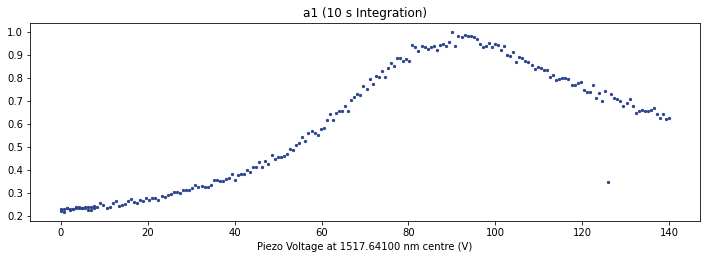

In [11]:
ylims_0310 = [[0, 8e3], 
              [0, 3e3], 
              [0, 3e3], 
              [0, 3e3]]

fVp_0310, fits_0310 = ang.spectra_by_pV(
    folderPath = sites_0310,
    numBins = 300,
    intTime = 10,
    excTime = 0.75e-3,
    countTime = 6e-3,
    deadCycle = 2,
    lines = linesFreq,
    ylims = ylims_0310,
    cols = ['#2B448C', 'dodgerblue', 'OrangeRed', 'orange'],
    norm = True,
    fit = True,
    fitWhichBins = [0, -1],
    save = True,
    savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed',
    desc = linesLabel)

In [ ]:
# fits = [x0, gamma, A, B, C]
fits_a1 = fits_0310['1517.64100']
fits_a2 = fits_0310['1528.81300']
fits_a3 = fits_0310['1533.93800']
fits_a7 = fits_0310['1534.58300']

# Motor Scan

In [50]:
def process_spectra_by_freq(folderPath, countWhichBins, 
                    intTime, excTime, countTime, deadCycle, aom, 
                    fit, fitWhichBins, ylims,
                    save = False, savePath = None, csvName = None):

    # READ INPUT DIRECTORY
    sortedFolders = sorted(folderPath,
                            key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]
        
    # EXTRACT DATA
    freqsVpeaksAll = {}
    fitsAll = {}
    fits = {}

    for i, wave in enumerate(subFolderWavelengths):
        totalCounts = []
        freqs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter = ",")
            times, data = fileRead[0], fileRead[1]
            freq = float(file.split("_")[2])
            counts = np.sum(data[countWhichBins[0]:countWhichBins[1]])
            timeLimit = [times[countWhichBins[0]], times[countWhichBins[1]]]
            totalCounts.append(counts)
            freqs.append(freq + float(aom))

        # INITIALISE FOR DATA STORAGE
        freqs = np.array(freqs)
        totalCounts = np.array(totalCounts)
        sortIdx = np.argsort(freqs)
        freqs = freqs[sortIdx]
        totalCounts = totalCounts[sortIdx]
   
        # NORMALISE TO COUNTS PER SECOND
        periodTTL = (excTime + countTime) * (deadCycle + 1) # [s]
        countTimeTotal = (intTime/periodTTL) * (timeLimit[1] - timeLimit[0]) # [s]
        countsPerSecond = totalCounts / countTimeTotal

        # # MASK SATURATED COUNTS PER SECOND
        # ylim = ylims[i] # select limits for each site
        # maxLim = ylim[1] # maximum 
        # mask = countsPerSecond < maxLim

        # freqs = freqs[mask]
        # countsPerSecond = countsPerSecond[mask]
        dataProcessed = pd.DataFrame({
            'Frequency (MHz)': freqs,
            'Counts per second': countsPerSecond
        })

        # FIT SPECTRUM
        if fit:
            try:
                whichBins = slice(fitWhichBins[0], fitWhichBins[1])
                # dataFit = np.column_stack(((freqsProcessed[whichBins])/1e3, 
                #                         countsPerSecondProcessed[whichBins])) # fit in GHz
                dataFit = np.column_stack(((freqs[whichBins])/1e3, 
                                        countsPerSecond[whichBins])) # fit in GHz
                x0, gamma, A, B, C = asym_lorentzian_fit(dataFit, None)
                fits = {
                    'x0': x0[0], 
                    'x0_err': x0[1],
                    'gamma': gamma[0], 
                    'gamma_err': gamma[1],
                    'A': A[0], 
                    'A_err': A[1],
                    'B': B[0], 
                    'B_err': B[1],
                    'C': C[0],
                    'C_err': C[1]
                    }
            except Exception as e:
                fits = None

        # STORE HERE AS DICTIONARY
        freqsVpeaksAll[wave] = dataProcessed
        fitsAll[wave] = fits

    # FLATTEN DICTIONARY TO SAVE DATA, FITS, AND TIMELIMIT
    if save:
        os.makedirs(savePath, exist_ok = True)
        for wave, df in freqsVpeaksAll.items():
            filename = f"{wave}_spectrum_{csvName}.csv"
            df.to_csv(os.path.join(savePath, filename), index = False)

        fits_df = pd.DataFrame.from_dict(fitsAll)
        fits_df = fits_df.reset_index()
        fits_df.to_csv(os.path.join(savePath, "lorentzian_fits.csv"), index = False)
            
    return freqsVpeaksAll, fitsAll, timeLimit

In [51]:
def process_spectra(folderPath,
                    countWhichBins,
                    intTime,
                    excTime,
                    countTime,
                    deadCycle,
                    freqOffset, # in MHz
                    ylims,
                    save,
                    savePath, 
                    dataID):
    sortedFolders = sorted(folderPath,
                        key = lambda x: os.path.basename(x))
    subFolderWavelengths = [os.path.basename(os.path.normpath(p)) for p in sortedFolders]

    # DATA ----------------------------------------------------- # 
    for i, wave in enumerate(subFolderWavelengths):
        peaks = []
        freqs = []
        pVs = []
        folder = sortedFolders[i]
        files = [f for f in os.listdir(folder) if f.endswith(".csv")]

        for file in files:
            file_path = os.path.join(folder, file)
            fileRead = np.loadtxt(file_path, delimiter=",")
            times, data = fileRead[0], fileRead[1]
            
            try:
                pV = float(file.split("_")[-2])
            except:
                pV = 'NaN'

            freq = float(file.split("_")[2]) + freqOffset
            counts = np.sum(data[countWhichBins[0]:countWhichBins[1]])
            timeLimit = [times[countWhichBins[0]], times[countWhichBins[1]]]
            maxLim = ylims[1]

            # Ignore saturated counts
            if counts > maxLim:
                counts = 0
            peaks.append(counts)
            freqs.append(freq)
            pVs.append(pV)

        freqs = np.array(freqs)
        totalCounts = np.array(peaks)

        # Normalise to counts per second
        periodTTL = (excTime + countTime) * (deadCycle + 1) # [s]
        countTimeTotal = (intTime/periodTTL) * (timeLimit[1] - timeLimit[0]) # [s]
        countsPerSecond = totalCounts / countTimeTotal

        fvpProcessed = pd.DataFrame({
            'Frequency (MHz)': freqs,
            'Counts per second': countsPerSecond
        })

        if save:
            dataPath = os.path.join(savePath, fr'{dataID}.csv')
            os.makedirs(savePath, exist_ok = True)
            fvpProcessed.to_csv(dataPath)

    return fvpProcessed, timeLimit

### Run 1 

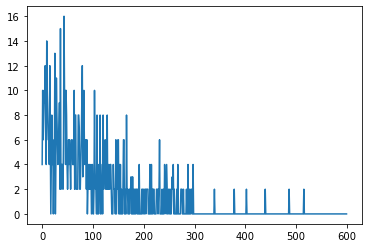

In [13]:
# Tune for number of bins
data = pd.read_csv(os.path.join(motor_0317[0], os.listdir(motor_0317[0])[-10]))
data = data.to_numpy()[0]
plt.plot(np.arange(0, len(data)), data)
plt.show()

In [54]:
ylims_0317 = [0, 1.5e4]
numBins = 200

# PROCESS PEAKS DATA
fVp_0317, timeLimit_0317 = process_spectra(motor_0317,
                           countWhichBins = [0, numBins],
                           intTime = 5,
                           excTime = 1e-3,
                           countTime = 6e-3,
                           deadCycle = 2,
                           freqOffset = 380,
                           ylims = ylims_0317,
                           save = True,
                           dataID = 'sic_motor_run1',
                           savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic\motor')

# EXTRACT RELEVANT ARRAYS
freqs_0317 = fVp_0317['Frequency (MHz)']
peaks_0317 = fVp_0317[f'Counts per second']

print(f'{timeLimit_0317[1]*1e3} ms')

4.0 ms


In [62]:
# Fit lifetimes
fitBins = [100, 300]
lifeVfreqs_0317 = np.zeros((len(os.listdir(motor_0317[0])), 3))
folder_path = motor_0317[0]
files = os.listdir(folder_path)

for i, file in enumerate(files):
    filepath = os.path.join(folder_path, file)
    data = np.loadtxt(filepath, delimiter=',')
    lifeVfreqs_0317[i, 0] = float(file.split("_")[2]) # store frequencies
    xA = data[0, fitBins[0]:fitBins[1]]
    yA = data[1, fitBins[0]:fitBins[1]]
    maskA = yA > 0
    xA = xA[maskA]
    yA = yA[maskA]
    try:
        slope, intercept, r, p, stderr = stats.linregress(xA, np.log(yA)) 
        life = -(1/slope) * 1e3 # ms
        lifeVfreqs_0317[i, 1] = life 
        lifeVfreqs_0317[i, 2] = life * stderr/slope
    except Exception as e:
        lifeVfreqs_0317[i, 1] = 1e-3      
time = data[0, :]
print(f'Time limit: {time[fitBins[0]]*1e3:.3f}, {time[fitBins[1]]*1e3:.3f} ms')

C:\Users\Mario\AppData\Local\Temp\ipykernel_10596\182369637.py:18: RuntimeWarning: divide by zero encountered in double_scalars
  life = -(1/slope) * 1e3 # ms
C:\Users\Mario\AppData\Local\Temp\ipykernel_10596\182369637.py:20: RuntimeWarning: invalid value encountered in double_scalars
  lifeVfreqs_0317[i, 2] = life * stderr/slope


Time limit: 2.000, 6.000 ms


In [68]:
lifeVfreqs_0317 = pd.DataFrame(lifeVfreqs_0317)
lifeVfreqs_0317.columns = ['Frequency (MHz)', 'T1 (ms)', 'T1 Error (ms)']
lifeVfreqs_0317.to_csv('all_T1s.csv')

In [79]:
foundData['Max Frequency (MHz)']

0     195000000.0
1     195000000.0
2     196000000.0
3     196000000.0
4     197000000.0
5     197000000.0
6     197000000.0
7     197000000.0
8     197000000.0
9     198000000.0
10    198000000.0
11    198000000.0
12    198000000.0
13    199000000.0
14    199000000.0
15    199000000.0
16    200000000.0
17    200000000.0
Name: Max Frequency (MHz), dtype: float64

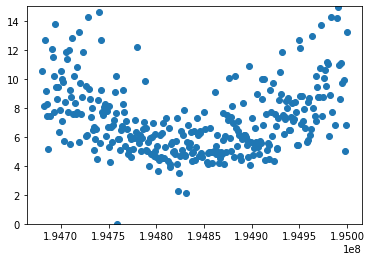

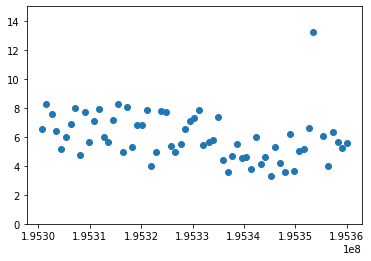

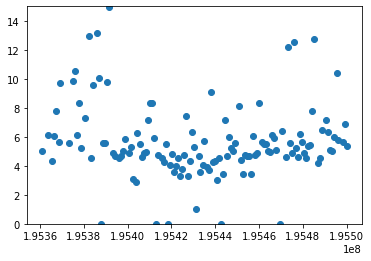

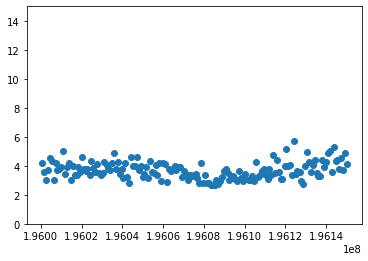

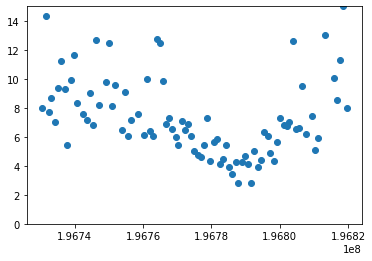

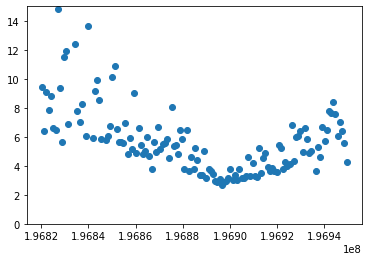

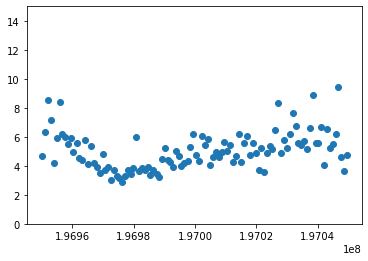

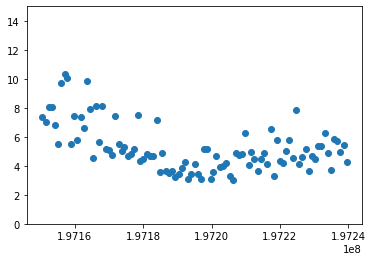

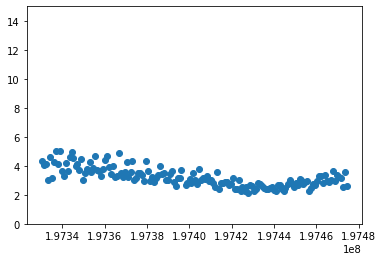

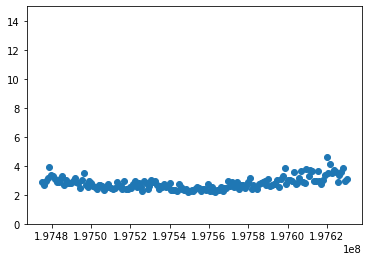

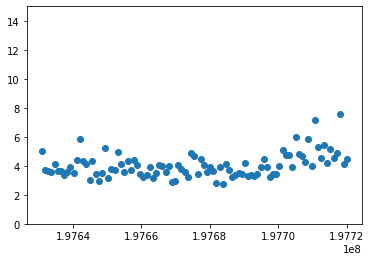

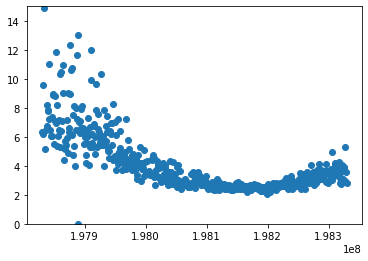

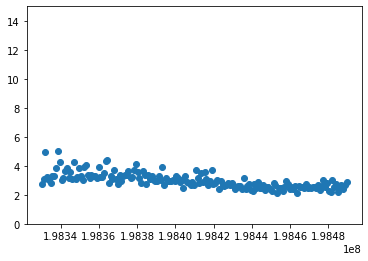

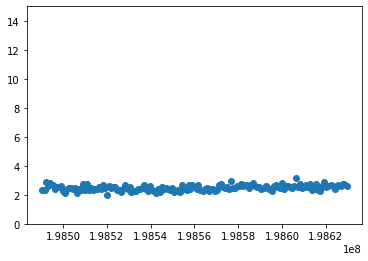

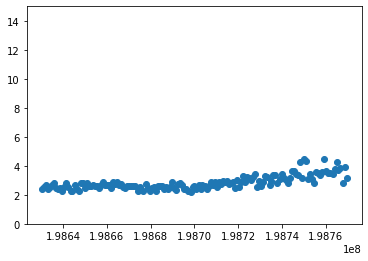

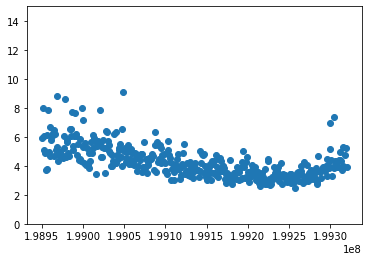

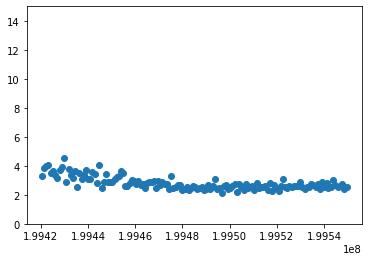

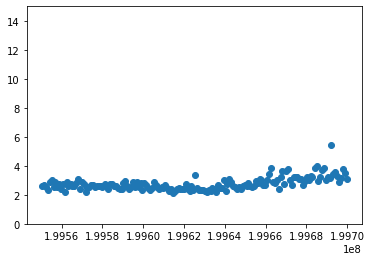

In [98]:
foundData = pd.read_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic\found_lines.csv',
                         delimiter = ',')

lifeVfreqs_0317 = lifeVfreqs_0317.sort_values(by = 'Frequency (MHz)')
freqs_0317 = lifeVfreqs_0317['Frequency (MHz)']
T1_0317 = lifeVfreqs_0317['T1 (ms)']
T1Err_0317 = lifeVfreqs_0317['T1 Error (ms)']

foundData = foundData.sort_values(by = 'Frequency (MHz)')
foundPeaks = foundData['Frequency (MHz)']
freqRangeMin = foundData['Min Frequency (MHz)']
freqRangeMax = foundData['Max Frequency (MHz)']

idx = range(len(foundPeaks))
freqsAll = np.array((freqs_0317 + 410))
T1All = np.array(T1_0317)
T1ErrAll = np.array(T1Err_0317)

# save each site according to min and max values
%matplotlib inline
savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic\lifetimes'
os.makedirs(savePath, exist_ok = True)

for i in idx:
    # print(i)
    # print(freqRangeMin[i], freqRangeMax[i])
    # print(freqsAll[(freqsAll > freqRangeMin[i]) &
    #            (freqsAll < freqRangeMax[i])])

    mask = (freqsAll > freqRangeMin[i]) & (freqsAll < freqRangeMax[i])
    freqs = freqsAll[mask]
    freqAvg = np.mean(freqs)
    T1 = T1All[mask]
    T1Err = T1ErrAll[mask]

    plt.ylim([0, 15])
    plt.scatter(freqs, T1)
    plt.ticklabel_format(useOffset = False)
    plt.show()

    fvp = pd.DataFrame({'Frequency (MHz)': freqs/1e3, 
                        'T1 (ms)': T1,
                        'T1 Error (ms)': T1Err})
                
    fvp.to_csv(f'{savePath}\{freqAvg/1e3:.3f} GHz.csv')

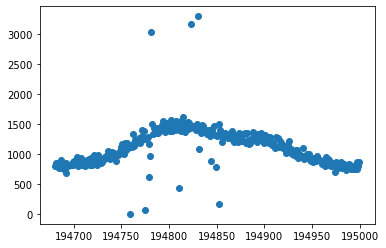

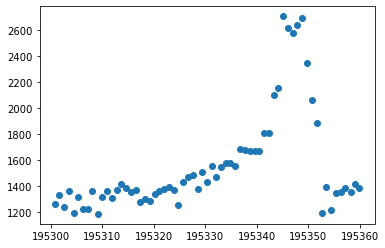

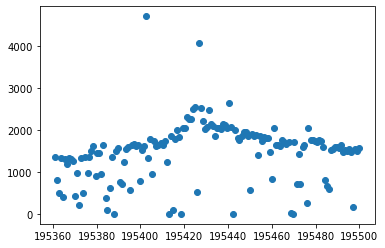

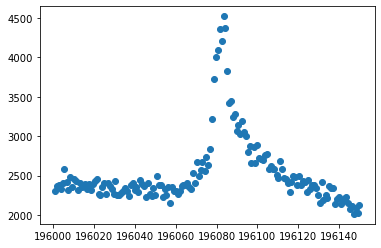

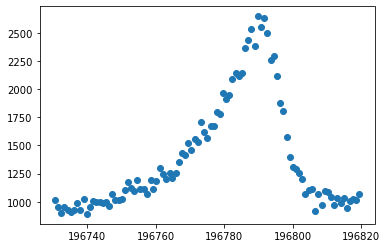

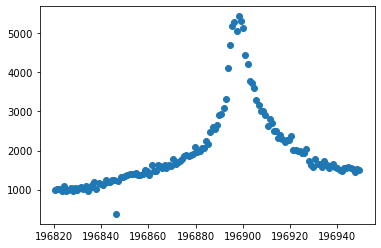

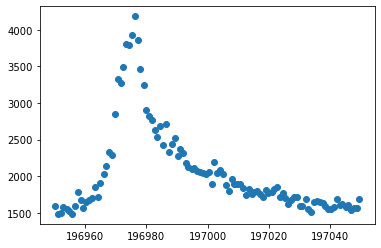

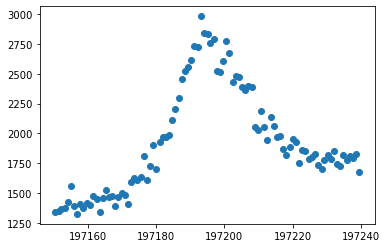

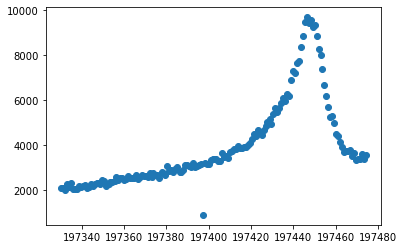

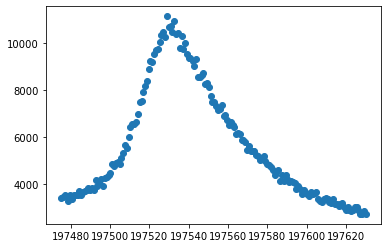

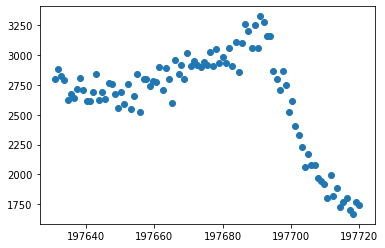

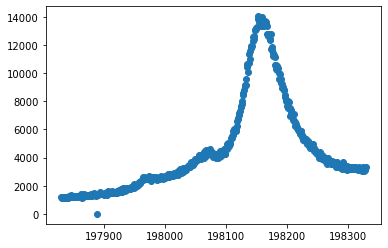

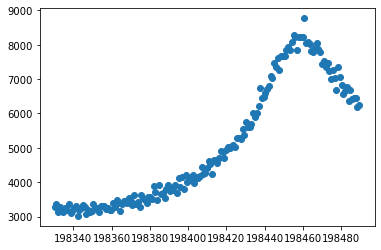

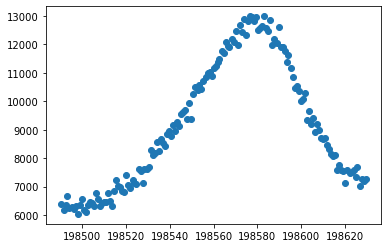

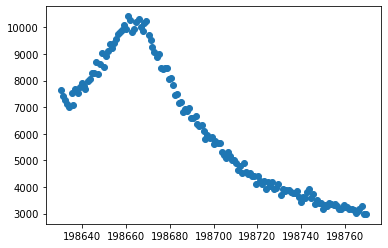

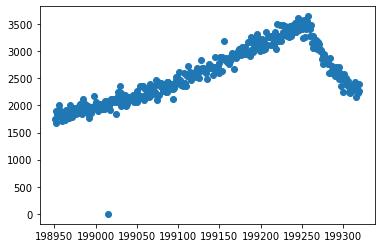

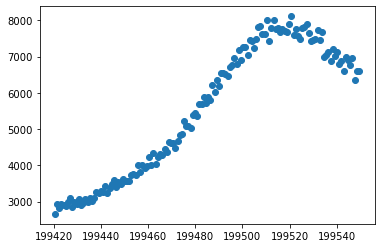

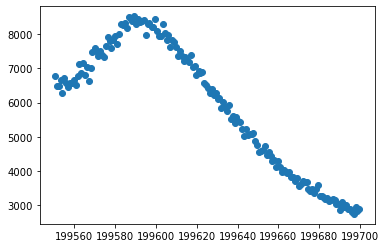

In [ ]:
foundData = pd.read_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\sic\motor\found_lines.csv',
                         delimiter = ',')

foundPeaks = foundData['Frequency (MHz)']
freqRangeMin = foundData['Min Frequency (MHz)']
freqRangeMax = foundData['Max Frequency (MHz)']
idx = foundData['Index']
freqsAll = np.array((freqs_0317 + 410)/1e3)
peaksAll = np.array(peaks_0317)

# save each site according to min and max values
%matplotlib inline
savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic\sites'
os.makedirs(savePath, exist_ok = True)

for i in idx:
    mask = (freqsAll > freqRangeMin[i]/1e3) & (freqsAll < freqRangeMax[i]/1e3)
    freqs = freqsAll[mask]
    freqAvg = np.mean(freqs)
    peaks = peaksAll[mask]

    plt.scatter(freqs, peaks)
    plt.ticklabel_format(useOffset = False)
    plt.show()

    fvp = pd.DataFrame({'Frequency (MHz)': freqs, 
                        'Counts': peaks})
                
    fvp.to_csv(f'{savePath}\{freqAvg/1e3:.3f} GHz.csv')

In [ ]:
# save each site according to min and max values
%matplotlib inline
savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic\lifetimes'
os.makedirs(savePath, exist_ok = True)

for i in idx:
    mask = (freqsAll > freqRangeMin[i]/1e3) & (freqsAll < freqRangeMax[i]/1e3)
    freqs = freqsAll[mask]
    freqAvg = np.mean(freqs)
    peaks = peaksAll[mask]

    plt.scatter(freqs, peaks)
    plt.ticklabel_format(useOffset = False)
    plt.show()

    fvp = pd.DataFrame({'Frequency (MHz)': freqs, 
                        'Counts': peaks})
                
    fvp.to_csv(f'{savePath}\{freqAvg/1e3:.3f} GHz.csv')

In [ ]:
readPath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic\sites'
siteFiles = os.listdir(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic\sites')
fitsAll = {}
# fvpAll = {}
fvpRows = []

for i, file in enumerate(siteFiles):
    data = pd.read_csv(os.path.join(readPath, file))
    freqs = data['Frequency (MHz)']
    peaks = data['Counts']

    x0, gamma, A, B, C = asym_lorentzian_fit(freqs, peaks, np.ones_like(freqs))

    fitsAll[f'{x0[0]:.3f}'] = {
        'x0': x0[0],
        'x0_err': x0[1],
        'gamma': gamma[0],
        'gamma_err': gamma[1],
        'A': A[0],
        'A_err': A[1],
        'B': B[0],
        'B_err': B[1],
        'C': C[0],
        'C_err': C[1],
    }

    fvpAll[f'{x0[0]:.3f}'] = {
        'Frequency (MHz)': freqs,
        'Counts': peaks 
    }

fits = pd.DataFrame(fitsAll).T
fits = fits.sort_values(by = ['x0'])
fits = fits.T

fvp = pd.DataFrame(fvpAll).T
fvp = fvp.T

savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-17\sic'
os.makedirs(savePath, exist_ok = True)

df = pd.DataFrame(fits)
df.to_csv(os.path.join(savePath, 'all_fits.csv'))

df = pd.DataFrame(fvp)
df.to_csv(os.path.join(savePath, 'all_fvp.csv'))

In [36]:
for key in fitsNfvp_sorted:
    print(key)

194811.185
195348.190
195426.915
196081.845
196790.988
196897.418
196973.563
197191.571
197449.071
197529.846
197700.624
198157.840
198457.387
198579.702
198664.857
199273.787
199507.163
199598.488


In [37]:
fitsNfvp_sorted

{'194811.185': x0                                               194811.185326
 x0_err                                                7.979784
 gamma                                               190.351725
 gamma_err                                            27.378152
 A                                                   929.189486
 A_err                                                90.427763
 B                                                     0.130268
 B_err                                                 0.049284
 C                                                   514.471533
 C_err                                               104.060291
 fvp          {'Frequency (MHz)': [194680.442, 194681.35, 19...
 Name: 194811.185, dtype: object,
 '195348.190': x0                                               195348.190083
 x0_err                                                0.240881
 gamma                                                 7.502725
 gamma_err                                

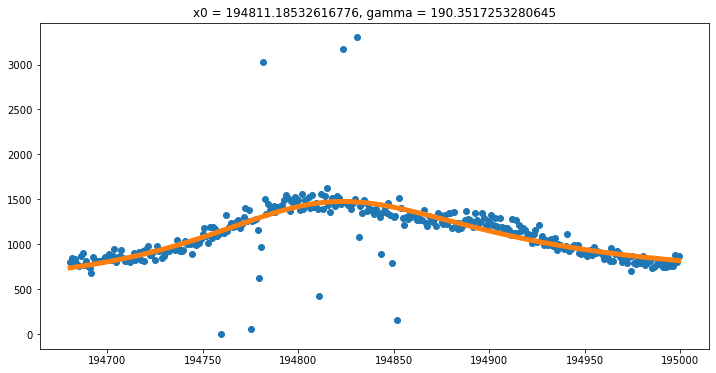

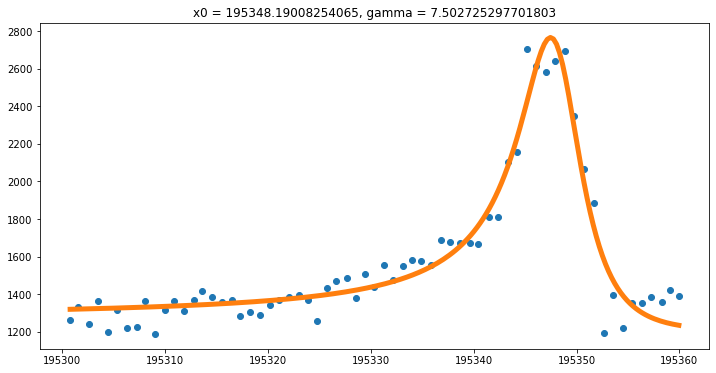

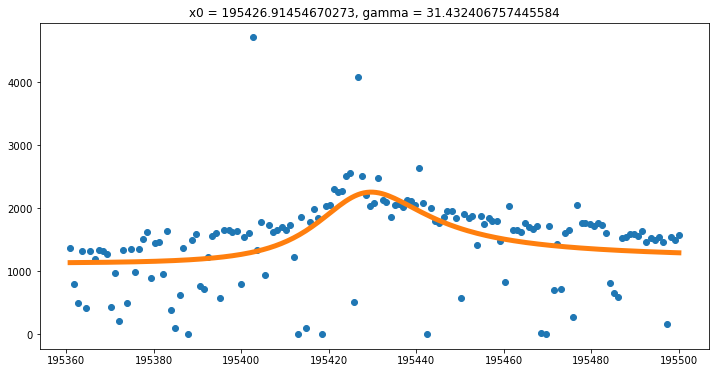

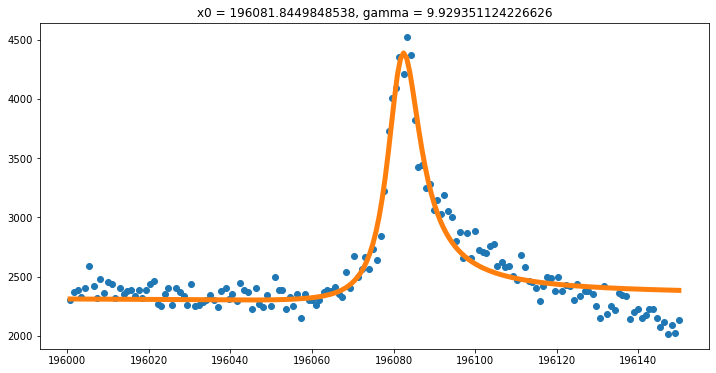

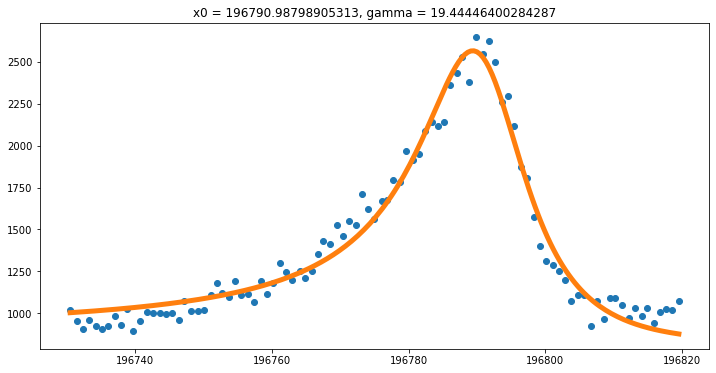

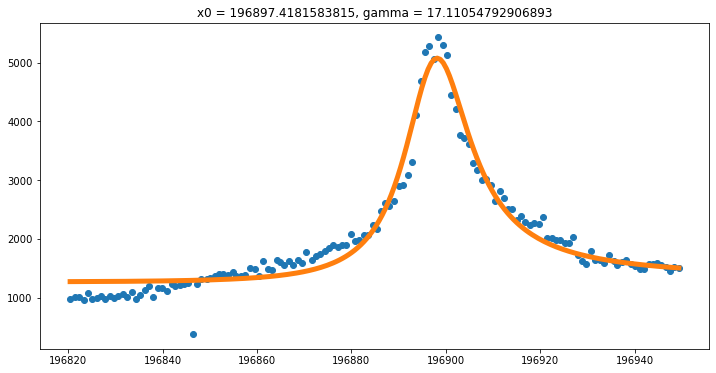

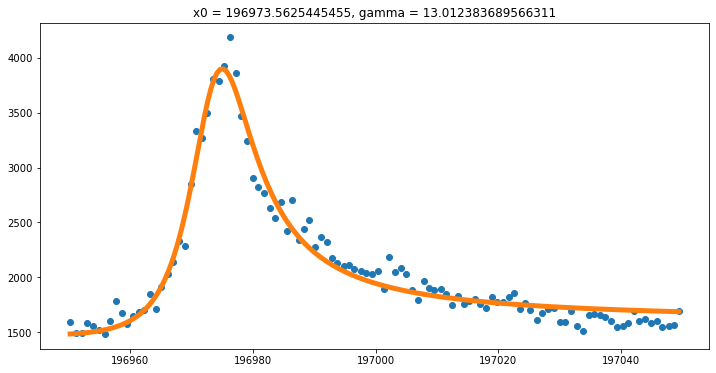

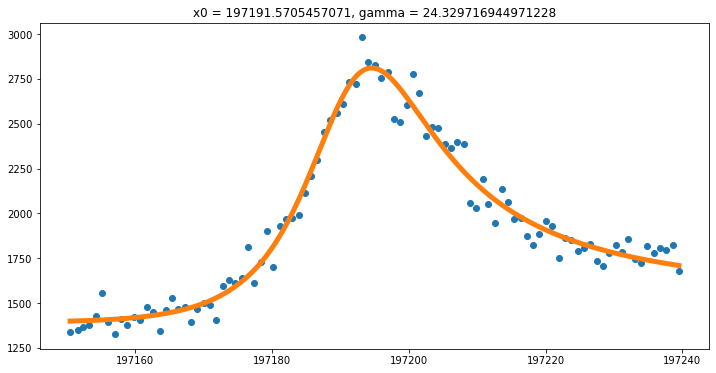

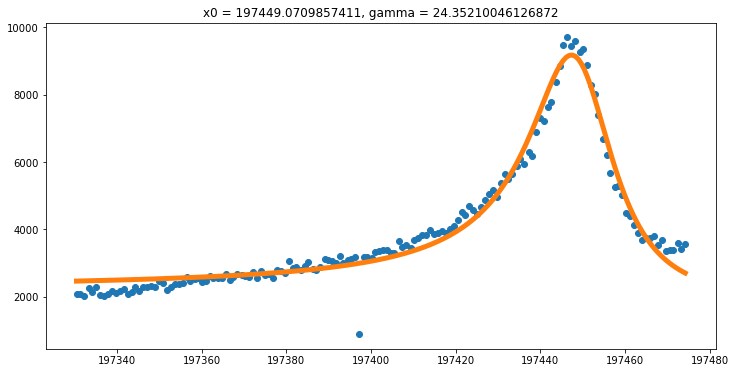

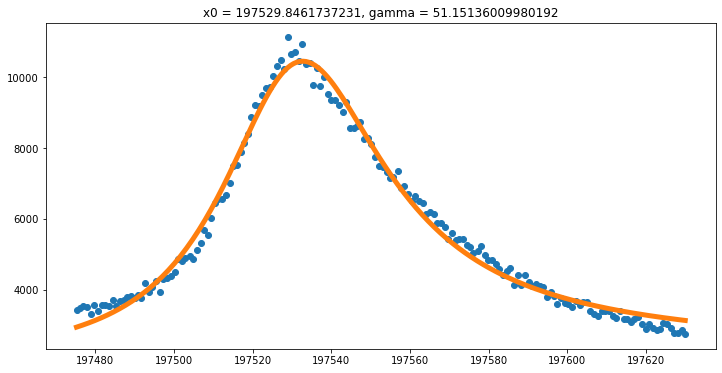

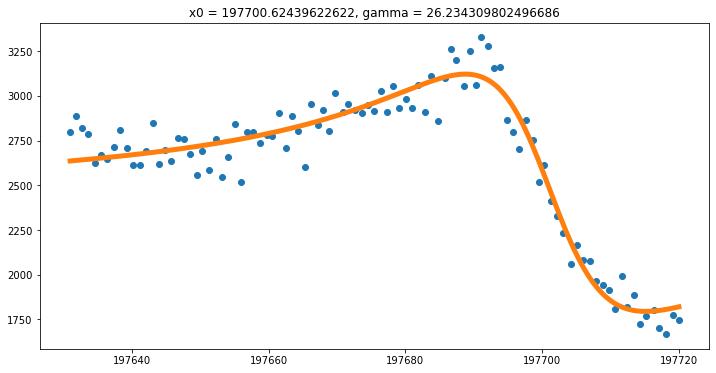

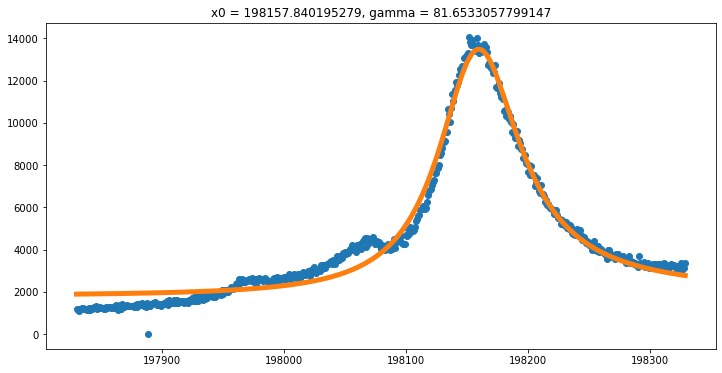

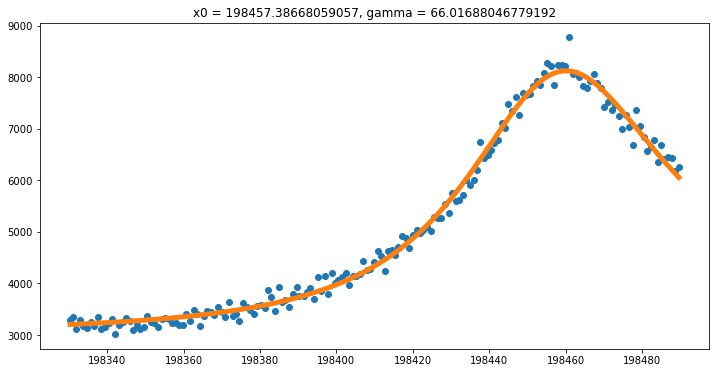

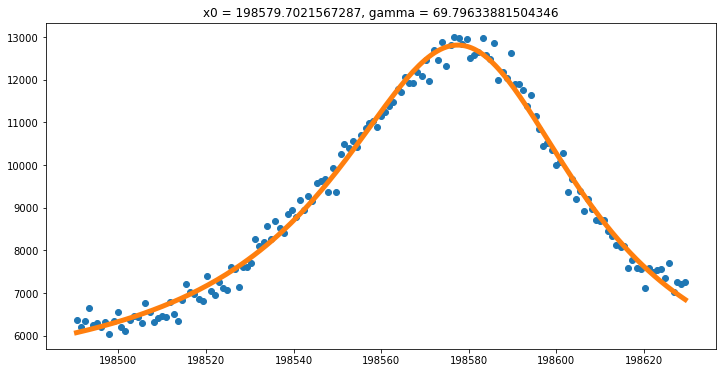

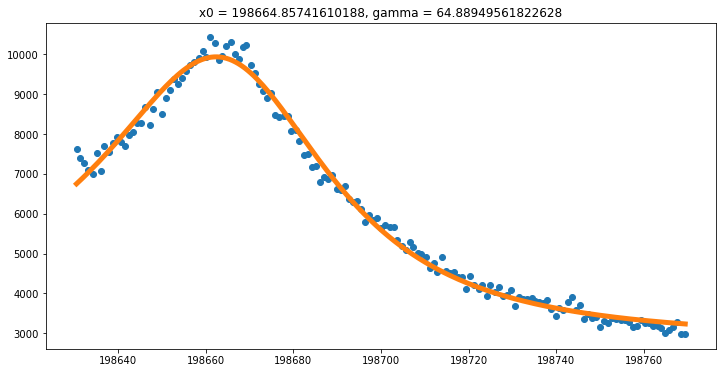

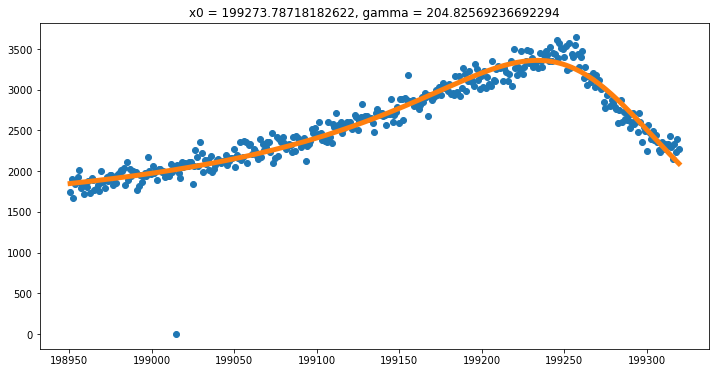

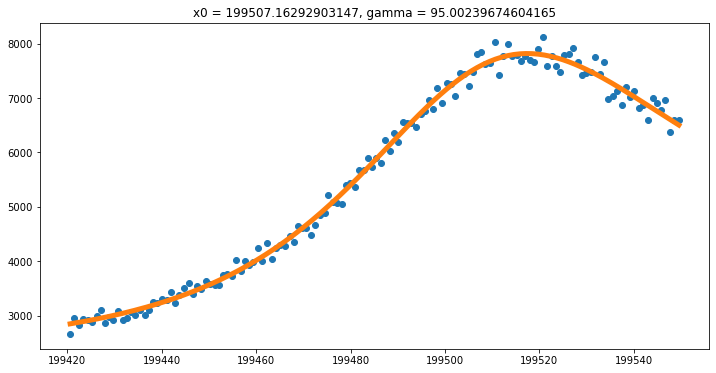

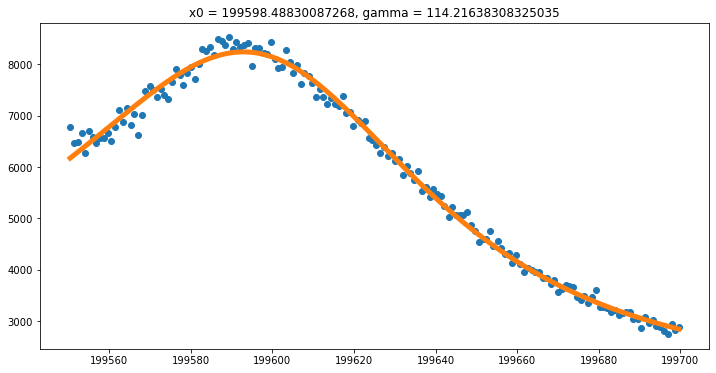

In [33]:
# plot fits
%matplotlib inline

for i, key in enumerate(fitsNfvp_sorted):
    row = fitsNfvp_sorted[key]
    freqs = row['fvp']['Frequency (MHz)']
    peaks = row['fvp']['Counts']

    x0 = row['x0']
    gamma = row['gamma']
    A = row['A']
    B = row['B']
    C = row['C']

    x = np.linspace(min(freqs), max(freqs), 200)
    y = asym_lorentzian(x, x0, gamma, A, B, C)

    plt.figure(figsize = (12, 6))
    plt.scatter(freqs, peaks)
    plt.plot(x, y, color = 'tab:orange', linewidth = 5)
    plt.title(fr'x0 = {x0}, gamma = {gamma}')
    plt.ticklabel_format(useOffset = False)

    plt.show()

### Wide Scan

In [196]:
# PLOT COLLATED DATA
# %matplotlib inline
%matplotlib 

c = 299792458  # m/s
def freq_to_wavelength(f_GHz):
    return c / (f_GHz * 1e9) * 1e9  # → nm

def wavelength_to_freq(l_nm):
    return c / (l_nm * 1e-9) / 1e9  # → GHz

fig, (ax0, ax1) = plt.subplots(
    2, 1,
    figsize = (12, 8),
    gridspec_kw = {'height_ratios': [2, 1]},
    sharex = True
)

f = (freqs_0317 + 410)/1e3
# Plot counts vs. frequency
ax0.scatter(f, peaks_0317, 
            c = '#2B448C', s = 0.2)
ax0.set_ylabel(rf'Counts', fontsize = 14)
ax0.xaxis.set_major_locator(ticker.MultipleLocator(1e3))
ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1e2))
ax0.tick_params(axis = 'both', labelsize = 12) 
ax0.vlines(foundPeaks/1e3, ymin = 0, ymax = 1.1 * max(peaks_0317), 
           colors = 'dodgerblue', linewidths = 1, alpha = 0.6, label = 'Inhomogeneous Lines')
ax0.set_ylim([0, 1.1 * max(peaks_0317)])
# ax0.set_xlim([193.25e3, 199.05e3])
# ax0.set_ylim(0, 8e3)

# Plot lifetimes vs. frequency
freqs = (lifeVfreqs_0317[:, 0] + 410)/1e3
T1s = lifeVfreqs_0317[:, 1]
T1errs = abs(errVfreqs_0317[:, 1])
ax1.scatter(freqs, T1s,
             c = 'OrangeRed', s = 0.2,
             label = r'T$_1$')
ax1.set_ylim([0, 80])
ax1.xaxis.set_major_locator(ticker.MultipleLocator(1e3))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(1e2))
# ax1.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax1.set_ylabel(rf'T$_1$ (ms)', fontsize = 14)
ax1.tick_params(axis = 'both', labelsize = 12) 
ax1.fill_between(freqs,
                T1s - T1errs,
                T1s + T1errs,
                color = '#FCA636FF',
                alpha = 0.4,
                linewidth = 0,
                label = r"T$_1$ standard error")
ax1.set_xlabel('Frequency (GHz)', fontsize = 14)

secax = ax0.secondary_xaxis(
    'top',
    functions=(freq_to_wavelength, wavelength_to_freq)
)
secax.set_xlabel('Wavelength (nm)', fontsize = 14)
secax.tick_params(axis = 'x', labelsize = 12)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_major_locator(ticker.MultipleLocator(10))
secax.xaxis.set_minor_locator(ticker.MultipleLocator(1))

ax0.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
ax0.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)
ax1.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
ax1.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)

ax0.legend(loc = 'upper right', fontsize = 12)
ax1.legend(loc = 'upper right', fontsize = 12)
plt.tight_layout()

# plt.savefig('sic motor.png')
plt.show()

Using matplotlib backend: QtAgg


C:\Users\Mario\AppData\Local\Temp\ipykernel_2448\2044320703.py:10: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


In [81]:
# PLOT COLLATED DATA
# %matplotlib inline
%matplotlib 

c = 299792458  # m/s
def freq_to_wavelength(f_GHz):
    return c / (f_GHz * 1e9) * 1e9  # → nm

def wavelength_to_freq(l_nm):
    return c / (l_nm * 1e-9) / 1e9  # → GHz

fig, ax0 = plt.subplots(1, figsize = (12, 6))

f = (freqs_0317 + 410)/1e3

ax0.scatter(f, peaks_0317, 
            c = '#2B448C', s = 5)
ax0.set_ylabel(rf'Counts', fontsize = 14)
ax0.xaxis.set_major_locator(ticker.MultipleLocator(1e3))
ax0.xaxis.set_minor_locator(ticker.MultipleLocator(1e2))
ax0.tick_params(axis = 'both', labelsize = 12) 
ax0.vlines(foundPeaks/1e3, ymin = 0, ymax = 1.1 * max(peaks_0317), 
           colors = 'dodgerblue', linewidths = 1, alpha = 0.6, label = 'Inhomogeneous Lines')
ax0.set_ylim([0, 1.1 * max(peaks_0317)])
# ax0.set_xlim([193.25e3, 199.05e3])
# ax0.set_ylim(0, 8e3)

secax = ax0.secondary_xaxis(
    'top',
    functions=(freq_to_wavelength, wavelength_to_freq)
)
secax.set_xlabel('Wavelength (nm)', fontsize = 14)
secax.tick_params(axis = 'x', labelsize = 12)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both') 
secax.xaxis.set_major_locator(ticker.MultipleLocator(10))
secax.xaxis.set_minor_locator(ticker.MultipleLocator(1))

ax0.grid(visible = True, which = 'major', axis = 'both', color = 'k', alpha = 0.2)
ax0.grid(visible = True, which = 'minor', axis = 'both', color = 'k', alpha = 0.05)

ax0.legend(loc = 'upper right', fontsize = 12)
plt.tight_layout()

# plt.savefig('sic motor.png')
plt.show()

Using matplotlib backend: QtAgg


C:\Users\Mario\AppData\Local\Temp\ipykernel_2448\1887942529.py:10: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz


In [ ]:
sicFound = pd.read_csv

In [ ]:
# Find peaks
%matplotlib
plt.ion()
find_IH_peaks_with_click(motor_freqs, motor_peaks, 
                         where= [8000, 10000],
                         desc = 'sic_motor_run1')

Using matplotlib backend: QtAgg
Click on the graph to select peaks. Press 'e' to complete selection.
Saved selected points to 2026_04_01_01_23_13_sic_motor_run1_bins8000_10000.csv


In [ ]:
d = {"col1": [0, 1, 2, 3], "col2": pd.Series([2, 3], index=[2, 3])}
pd.DataFrame(data=d, index=[0, 1, 2, 3])

In [ ]:
# Concatenate found peaks
sic_motor = (glob.glob(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\sic\motor\*'))
foundFreqs_0317 = np.array([])
foundPeaks_0317 = np.array([])

for file in sic_motor:
    data = pd.read_csv(file)
    freqs = np.array(data['Frequency (GHz)'])
    foundFreqs_0317 = np.concatenate((foundFreqs_0317, freqs))
    peaks = np.array(data['Signal'])
    foundPeaks_0317 = np.concatenate((foundPeaks_0317, peaks))
    found_lines = pd.DataFrame({'Frequency (MHz)': foundFreqs_0317, 
                                'Counts': foundPeaks_0317})

found_lines.to_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\analysis\data processed\peak picking data\sic\motor\found_lines.csv')
# np.savetxt('found_lines.csv', foundFreqs_0317, delimiter = ',')

In [7]:
%matplotlib inline
# %matplotlib
# plt.ion()
# plt.ioff()

# PLOT DATA
plot_motor(fVp_0317,
           numBins = 200,
           where = where,
           intTime = 4.5,
           excTime = 1e-3,
           timeLimit = timeLimit_0317,
           aom = 380,
           ylims = ylims_0317,
           cols = ['#2B448C', 'dodgerblue', 'OrangeRed'],
           save = True,
           plotPath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\plots processed\2026-03-17\sic\motor',
           plotDesc = fr'Implanted 4H Er:SiC in Confocal (4.5 s Integration)',
           motorID = 1, 
        #    foundLines = foundFreqs_0317,
           lifeVfreqs = lifeVfreqs)

NameError: name 'plot_motor' is not defined

### Run 2

In [ ]:
ylims_0318 = [0, 1e6]
numBins = 200

# PROCESS DATA
fVp_0318, timeLimit_0318 = process_motor(motor_0318,
                           numBins = numBins,
                           ylims = ylims_0318,
                           save = True,
                           dataID = 'sic_motor_run2',
                           savePath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\data processed\2026-03-18\sic\motor')

165    195496193.0
Name: Frequencies (MHz), dtype: float64


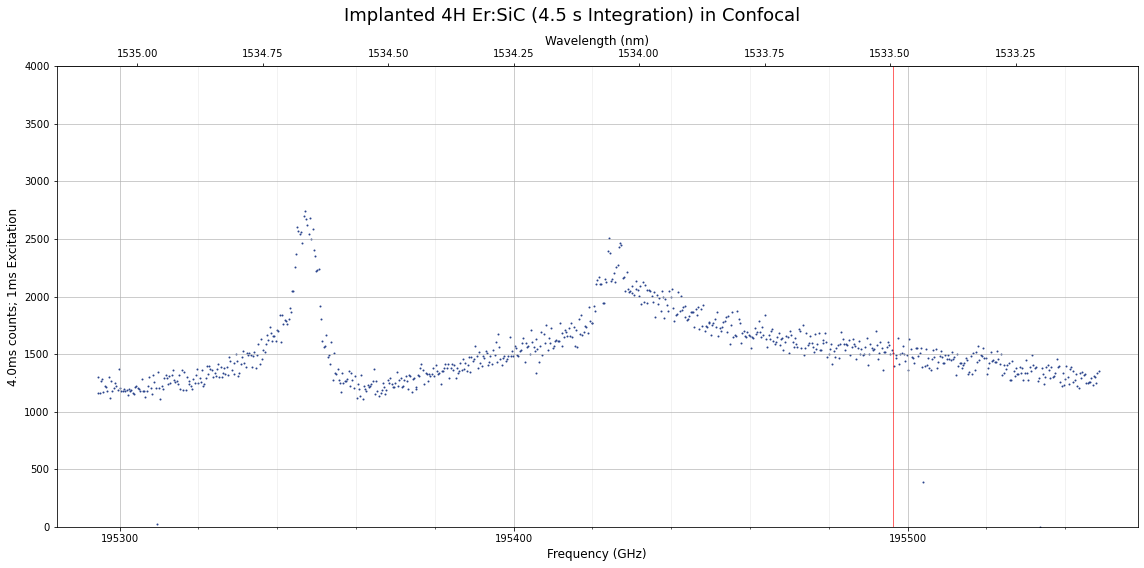

In [ ]:
# FIND PEAKS
%matplotlib inline
peaks_0318 = fVp_0318[f'Counts over {timeLimit_0318 * 1e3} ms']
foundPeaks_0318 = peak.find_peaks(peaks_0318, 
                height = [2500, 3000],
                width = 20,
                prominence = 0.8 * np.max(peaks_0318))[0]
foundFreqs_0318 = fVp_0318[f'Frequencies (MHz)'][foundPeaks_0318]
print(foundFreqs_0318)

# PLOT DATA
plot_motor(fVp_0318,
           numBins = 200,
           where = [0, len(fVp_0318) - 1],
           intTime = 4.5,
           excTime = 1e-3,
           timeLimit = timeLimit_0318,
           aom = 380,
           ylims = [0, 4e3],
           cols = ['#2B448C', 'dodgerblue', 'OrangeRed'],
           save = False,
           plotPath = r'C:\Users\Mario\Documents\GitHub\Angela Honours\plots processed\2026-03-17\sic\motor',
           plotDesc = fr'Implanted 4H Er:SiC (4.5 s Integration) in Confocal',
           motorID = 2,
           foundLines = foundFreqs_0318)

# Lifetimes

In [ ]:
cols = ['#2B448C', '#CE5F2C', 'dodgerblue', 'OrangeRed']

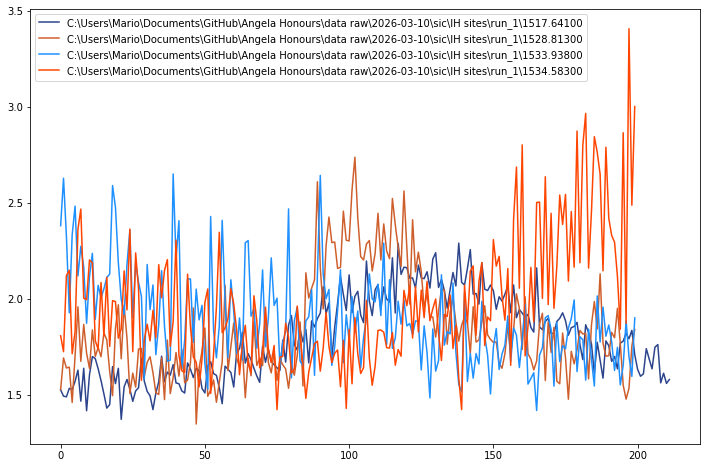

Time limit: 3.00 ms


In [ ]:
%matplotlib inline

lifetime_dict = {}
plt.figure(figsize = (12, 8))

for j, folder_path in enumerate(sites_0310):
    
    files = os.listdir(folder_path)
    lifetimes = np.zeros(len(files))
    
    for i, file in enumerate(files):
        filepath = os.path.join(folder_path, file)
        data = np.loadtxt(filepath, delimiter=',')

        xA = data[0, 0:150]
        yA = data[1, 0:150]

        maskA = yA > 0
        xA = xA[maskA]
        yA = yA[maskA]

        slopeA, interceptA, *_ = stats.linregress(xA, np.log(yA))        
        
        lifetimes[i] = -(1/slopeA) * 1e3  # ms

    # use folder name as key (or replace with wavelength if encoded)
    lifetime_dict[folder_path] = lifetimes
    plt.plot(np.arange(len(files)), lifetimes, c=cols[j], label=f"{folder_path}")

plt.legend()
plt.show()

print(f'Time limit: {data[0, 150]*1e3:.2f} ms')

In [55]:
# DEFINE FUNCTION FOR EXTRACTING LIFETIMES, SORTED BY FREQUENCY
lifeVfreqs = np.zeros((len(os.listdir(motor_0317[0])), 2))
folder_path = motor_0317[0]
files = os.listdir(folder_path)

for i, file in enumerate(files):
    filepath = os.path.join(folder_path, file)
    data = np.loadtxt(filepath, delimiter=',')
    lifeVfreqs[i, 0] = float(file.split("_")[2]) # store frequencies
    xA = data[0, 0:150]
    yA = data[1, 0:150]
    maskA = yA > 0
    xA = xA[maskA]
    yA = yA[maskA]
    try:
        slopeA, interceptA, *_ = stats.linregress(xA, np.log(yA)) 
        lifeVfreqs[i, 1] = -(1/slopeA) * 1e3  # ms
    except Exception as e:
        lifeVfreqs[i, 1] = 1e-3      

print(f'Time limit: {data[0, 150]*1e3:.2f} ms')

C:\Users\Mario\AppData\Local\Temp\ipykernel_10596\1941288492.py:17: RuntimeWarning: divide by zero encountered in double_scalars
  lifeVfreqs[i, 1] = -(1/slopeA) * 1e3  # ms


Time limit: 3.00 ms


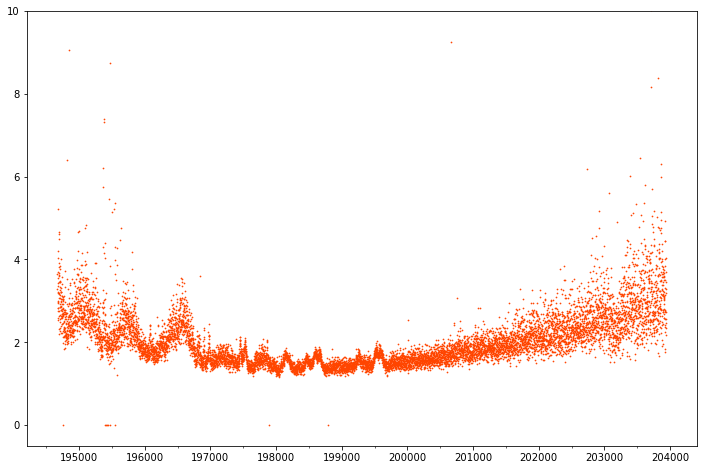

In [ ]:
%matplotlib inline
plt.ioff()

fig, ax = plt.subplots(figsize = (12, 8))
ax.scatter(lifeVfreqs[:, 0]/1e3, lifeVfreqs[:, 1],
             c = cols[3], s = 0.5)
ax.set_ylim([-0.5, 10])
ax.xaxis.set_major_locator(ticker.MultipleLocator(1e3))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5e3))
plt.show()

# Silicon Sandwich Spectrum

In [8]:
si = pd.read_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\silicon sandwich\20260422.csv',
                 dtype = None, index_col = 0)

C:\Users\Mario\AppData\Local\Temp\ipykernel_3624\1772961671.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  si = pd.read_csv(r'C:\Users\Mario\Documents\GitHub\Angela Honours\data raw\silicon sandwich\20260422.csv',


In [ ]:
f = si['measured_frequency']
f = f[si['chip'] == 'Er2022_16X_natSi_FZ14B']
r = si['counts_per_repetition']
r = r[si['chip'] == 'Er2022_16X_natSi_FZ14B']

In [44]:
%matplotlib
c = 299792458  # m/s
def freq_to_wavelength(f_GHz):
    return c / (f_GHz * 1e9) * 1e9  # → nm

def wavelength_to_freq(l_nm):
    return c / (l_nm * 1e-9) / 1e9  # → GHz

fig, ax = plt.subplots(1, 1, figsize = (12, 8))

ax.scatter(f, r, s = 0.2)
ax.tick_params(axis = 'both', labelsize = 12) 
ax.set_xlabel('Frequency (GHz)', fontsize = 14)

secax = ax.secondary_xaxis(
    'top',
    functions=(freq_to_wavelength, wavelength_to_freq)
)
secax.set_xlabel('Wavelength (nm)', fontsize = 14)
secax.tick_params(axis = 'x', labelsize = 12)  
secax.ticklabel_format(style = 'plain', useOffset = False, axis = 'both')

plt.show()

Using matplotlib backend: QtAgg


C:\Users\Mario\AppData\Local\Temp\ipykernel_3624\1341156502.py:7: RuntimeWarning: divide by zero encountered in divide
  return c / (l_nm * 1e-9) / 1e9  # → GHz
